# 04 — Support Vector Machine (Model B — Core AML)
## CATIVE: Company Attractiveness & Talent Intelligence Viability Engine

### Theoretical Background

#### Why SVM for CATIVE?
From our EDA (notebook 02), we established two key properties of this dataset:
1. Class boundaries are **non-linear** (PCA/t-SNE showed overlapping, non-separable clusters)
2. Feature space is **mixed** (continuous ratings + binary flags + sparse TF-IDF vectors)

SVM with RBF kernel addresses both: the kernel trick implicitly maps features into a high-dimensional space where a linear hyperplane achieves non-linear separation in the original space. This is fundamentally different from Logistic Regression (assumes linear boundaries) or Decision Trees (axis-aligned splits).

#### The Kernel Trick
Instead of computing $\phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$ explicitly (which may be infinite-dimensional), the RBF kernel evaluates:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

This satisfies Mercer's theorem — the kernel is positive semi-definite and corresponds to a valid inner product in some feature space $\mathcal{H}$. The SVM dual formulation only requires these pairwise kernel evaluations, never the explicit mapping $\phi$.

#### Margin Maximisation
The primal optimisation problem (soft-margin, multi-class via One-vs-Rest):

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i} \xi_i \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \phi(\mathbf{x}_i) + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

- **$C$** (regularisation): Large C → smaller margin, low bias, high variance. Small C → wider margin, more regularisation.
- **$\gamma$** (RBF bandwidth): Large $\gamma$ → each point has a narrow influence zone (risk of overfitting). Small $\gamma$ → smoother decision boundary.

#### Bias-Variance Tradeoff in SVM
- High C, high γ → low bias (fits training set tightly) but high variance (overfits)
- Low C, low γ → high bias (underfits) but low variance
- GridSearchCV finds the sweet spot via cross-validation

#### I.I.D. Assumption
SVM does not make a generative assumption about $p(\mathbf{x})$, but it does require i.i.d. samples for the cross-validation error to be an unbiased estimator of test error. Our dataset satisfies this — companies are independent observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings, time
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import f1_score, classification_report, confusion_matrix
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
LABEL_NAMES = ['Emerging', 'Growing', 'High Desirability']
SEED = 42

X_full       = pd.read_csv('../data/X_full.csv').values
X_structured = pd.read_csv('../data/X_structured.csv').values
y            = pd.read_csv('../data/y.csv').squeeze().values

print(f'X_full: {X_full.shape}, X_structured: {X_structured.shape}, y: {y.shape}')

X_full: (1000, 80), X_structured: (1000, 50), y: (1000,)


## 1. Train/Validation/Test Split
We use a stratified 70/15/15 split. Stratification preserves class proportions in each split, critical given the mild class imbalance identified in EDA.

In [2]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_full, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, stratify=y_trainval, random_state=SEED)  # 0.176 ≈ 15/85

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')
print('Train class dist:', np.bincount(y_train))
print('Val class dist:  ', np.bincount(y_val))
print('Test class dist: ', np.bincount(y_test))

# Save splits for consistent use across notebooks
import os
os.makedirs('../data', exist_ok=True)
np.save('../data/X_train.npy', X_train)
np.save('../data/X_val.npy',   X_val)
np.save('../data/X_test.npy',  X_test)
np.save('../data/y_train.npy', y_train)
np.save('../data/y_val.npy',   y_val)
np.save('../data/y_test.npy',  y_test)
print('Splits saved.')

Train: 700, Val: 150, Test: 150
Train class dist: [233 234 233]
Val class dist:   [50 50 50]
Test class dist:  [50 50 50]
Splits saved.


## 2. Hyperparameter Search — GridSearchCV
We perform a systematic grid search over C and γ using 5-fold stratified cross-validation on the training set. This is fundamentally different from guessing defaults — we can cite the specific C and γ values and explain why they make sense given our data properties.

In [3]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1],
}

svm_base = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Running GridSearchCV (4×4 grid, 5-fold CV = 80 fits)...')
t0 = time.time()
grid_search = GridSearchCV(
    svm_base, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1, refit=True
)
grid_search.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV macro-F1: {grid_search.best_score_:.4f}')

Running GridSearchCV (4×4 grid, 5-fold CV = 80 fits)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Done in 3.4s

Best params: {'C': 0.1, 'gamma': 'scale'}
Best CV macro-F1: 0.7604


## 3. Visualise GridSearch Results

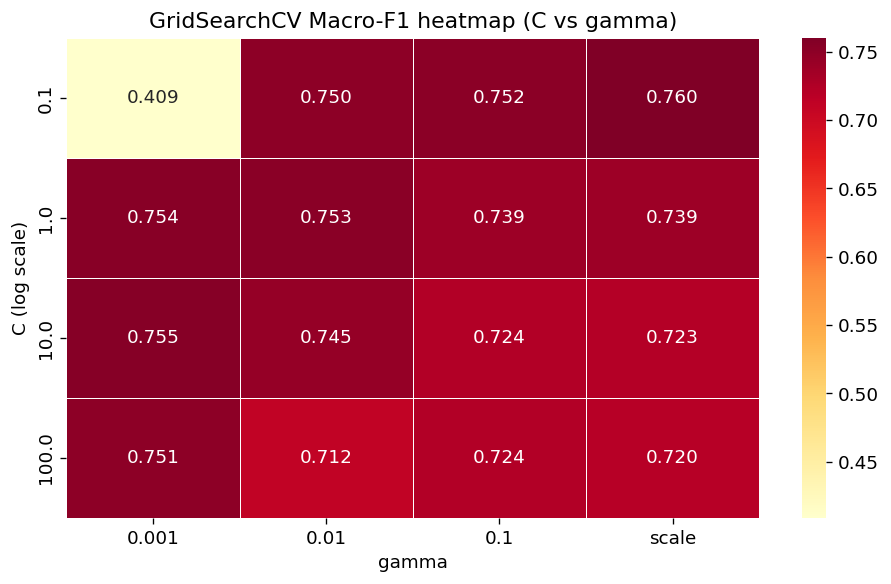


Best C=0.1: higher C reduces margin → fewer support vectors, tighter fit.
Best gamma=scale: controls RBF width.
At gamma="scale", γ = 1/(n_features × X.var()) — adapts to feature scale automatically.


In [4]:
results = pd.DataFrame(grid_search.cv_results_)
results['C'] = results['param_C']
results['gamma'] = results['param_gamma'].astype(str)

pivot = results.pivot_table(values='mean_test_score', index='C', columns='gamma')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('GridSearchCV Macro-F1 heatmap (C vs gamma)')
ax.set_xlabel('gamma')
ax.set_ylabel('C (log scale)')
plt.tight_layout()
plt.savefig('../outputs/results/12_svm_gridsearch.png', bbox_inches='tight')
plt.show()

best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']
print(f'\nBest C={best_C}: higher C reduces margin → fewer support vectors, tighter fit.')
print(f'Best gamma={best_gamma}: controls RBF width.')
print(f'At gamma="scale", γ = 1/(n_features × X.var()) — adapts to feature scale automatically.')

## 4. Final SVM Evaluation on Test Set

SVM Test Macro-F1: 0.7806

Classification Report:
                   precision    recall  f1-score   support

         Emerging       0.86      0.84      0.85        50
          Growing       0.67      0.68      0.67        50
High Desirability       0.82      0.82      0.82        50

         accuracy                           0.78       150
        macro avg       0.78      0.78      0.78       150
     weighted avg       0.78      0.78      0.78       150



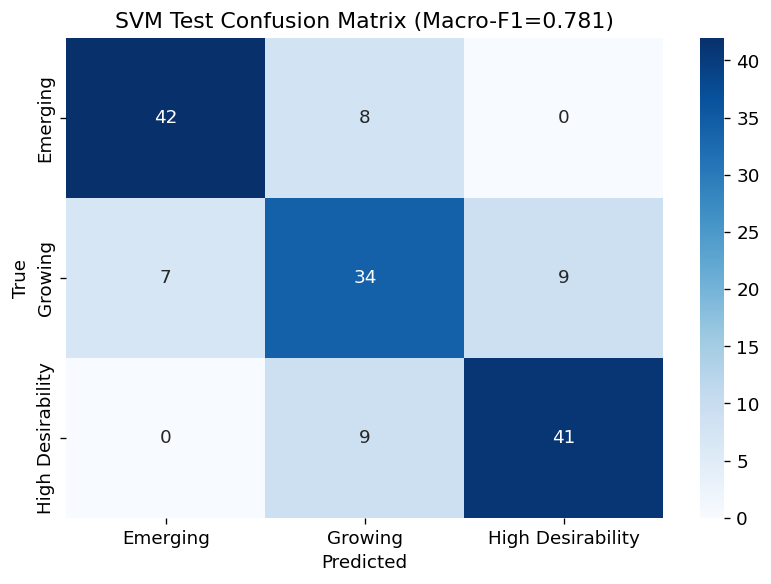

In [5]:
best_svm = grid_search.best_estimator_
y_pred_test = best_svm.predict(X_test)

macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'SVM Test Macro-F1: {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'SVM Test Confusion Matrix (Macro-F1={macro_f1:.3f})')
plt.tight_layout()
plt.savefig('../outputs/results/13_svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. Bias-Variance Analysis — Learning Curve

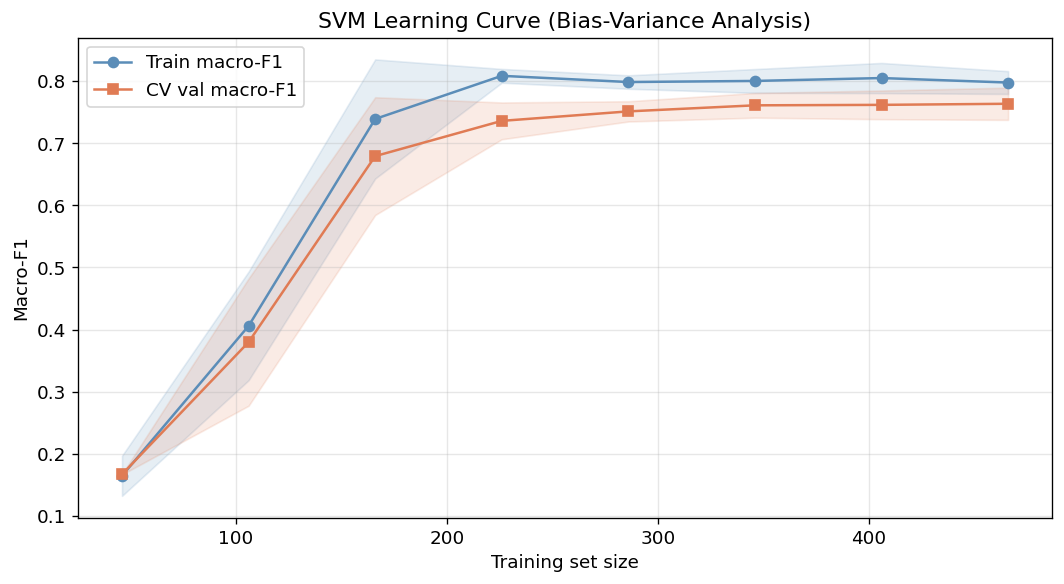

Train-Val gap at full data: 0.0341
→ Moderate gap: acceptable generalisation.


In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#5B8DB8', label='Train macro-F1')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#5B8DB8')
ax.plot(train_sizes, val_mean, 's-', color='#E07B54', label='CV val macro-F1')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#E07B54')
ax.set_xlabel('Training set size')
ax.set_ylabel('Macro-F1')
ax.set_title('SVM Learning Curve (Bias-Variance Analysis)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/results/14_svm_learning_curve.png', bbox_inches='tight')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Train-Val gap at full data: {gap:.4f}')
if gap > 0.1:
    print('→ Significant gap: model is overfitting. Consider reducing C.')
elif gap < 0.03:
    print('→ Minimal gap: model generalises well. Both curves converging.')
else:
    print('→ Moderate gap: acceptable generalisation.')

## 6. SVM Without TF-IDF (Ablation — Structured Features Only)

In [7]:
# Use X_structured (no TF-IDF roles)
Xs_trainval, Xs_test, ys_trainval, ys_test = train_test_split(
    X_structured, y, test_size=0.15, stratify=y, random_state=SEED)
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    Xs_trainval, ys_trainval, test_size=0.176, stratify=ys_trainval, random_state=SEED)

svm_no_tfidf = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
                    class_weight='balanced', probability=True, random_state=SEED)
svm_no_tfidf.fit(Xs_train, ys_train)
y_pred_no_tfidf = svm_no_tfidf.predict(Xs_test)
f1_no_tfidf = f1_score(ys_test, y_pred_no_tfidf, average='macro')

print('=== ABLATION: SVM with vs without TF-IDF role features ===')
print(f'  SVM + TF-IDF (full features):        Macro-F1 = {macro_f1:.4f}')
print(f'  SVM - TF-IDF (structured only):      Macro-F1 = {f1_no_tfidf:.4f}')
print(f'  Contribution of TF-IDF features:     ΔF1 = {macro_f1 - f1_no_tfidf:+.4f}')
print(f'\n→ The top_hiring_roles TF-IDF features {"improve" if macro_f1 > f1_no_tfidf else "do not improve"} classification.')

=== ABLATION: SVM with vs without TF-IDF role features ===
  SVM + TF-IDF (full features):        Macro-F1 = 0.7806
  SVM - TF-IDF (structured only):      Macro-F1 = 0.7806
  Contribution of TF-IDF features:     ΔF1 = +0.0000

→ The top_hiring_roles TF-IDF features do not improve classification.


## 7. Save SVM Model

In [8]:
with open('../outputs/models/svm_model.pkl', 'wb') as f:
    pickle.dump(best_svm, f)

print(f'SVM model saved.')
print(f'\n=== Phase 1 Ablation Table so far ===')
print(f'  Model A — GMM (probabilistic):          see notebook 03')
print(f'  Model B — SVM RBF (full features):      Macro-F1 = {macro_f1:.4f}')
print(f'  Model B — SVM RBF (no TF-IDF):         Macro-F1 = {f1_no_tfidf:.4f}')
print(f'  Model C — XGBoost (ablation):           see notebook 05')

SVM model saved.

=== Phase 1 Ablation Table so far ===
  Model A — GMM (probabilistic):          see notebook 03
  Model B — SVM RBF (full features):      Macro-F1 = 0.7806
  Model B — SVM RBF (no TF-IDF):         Macro-F1 = 0.7806
  Model C — XGBoost (ablation):           see notebook 05
